# Building a neural network FROM SCRATCH (no Tensorflow/Pytorch, just numpy & math)

#### https://www.youtube.com/watch?v=w8yWXqWQYmU

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
from pathlib import Path

In [14]:
file_folder = 'OneDrive - Prescient\py\kaggle_datasets'
file_name   = 'train.csv'
data        = pd.read_csv(os.path.join(Path.home(), file_folder, file_name))
m, n = data.shape
print(f'{examples} rows of examples, {features-1} columns of features')

42000 rows of examples, 784 columns of features


In [3]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [4]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    return np.exp(Z) / sum(np.exp(Z))
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [5]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [6]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[6 1 6 ... 6 3 1] [2 1 8 ... 1 2 3]
0.13117073170731708
Iteration:  10
[6 1 6 ... 7 7 3] [2 1 8 ... 1 2 3]
0.1979268292682927
Iteration:  20
[6 1 6 ... 7 7 3] [2 1 8 ... 1 2 3]
0.2626341463414634
Iteration:  30
[6 1 4 ... 7 4 3] [2 1 8 ... 1 2 3]
0.33887804878048783
Iteration:  40
[4 1 2 ... 7 4 3] [2 1 8 ... 1 2 3]
0.4091463414634146
Iteration:  50
[4 1 2 ... 7 4 3] [2 1 8 ... 1 2 3]
0.47248780487804876
Iteration:  60
[4 1 2 ... 1 4 3] [2 1 8 ... 1 2 3]
0.5242682926829269
Iteration:  70
[4 1 2 ... 1 2 5] [2 1 8 ... 1 2 3]
0.5655853658536585
Iteration:  80
[6 1 8 ... 1 2 5] [2 1 8 ... 1 2 3]
0.5974878048780488
Iteration:  90
[6 1 8 ... 1 2 5] [2 1 8 ... 1 2 3]
0.6219756097560976
Iteration:  100
[4 1 8 ... 1 2 5] [2 1 8 ... 1 2 3]
0.6434634146341464
Iteration:  110
[4 1 8 ... 1 2 5] [2 1 8 ... 1 2 3]
0.662609756097561
Iteration:  120
[4 1 8 ... 1 2 5] [2 1 8 ... 1 2 3]
0.6790243902439025
Iteration:  130
[4 1 8 ... 1 2 5] [2 1 8 ... 1 2 3]
0.6938536585365853
Iteration:  140

In [7]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [2]
Label:  2


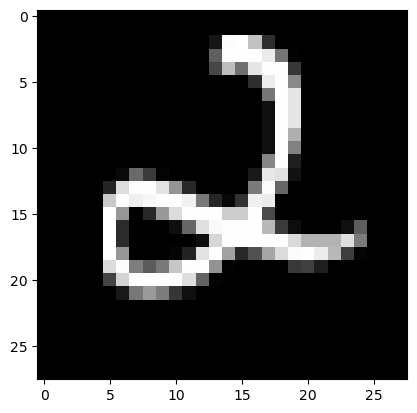

Prediction:  [1]
Label:  1


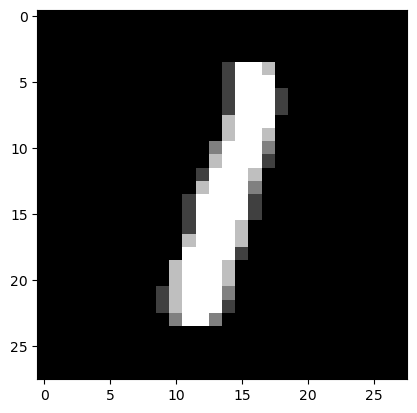

Prediction:  [8]
Label:  8


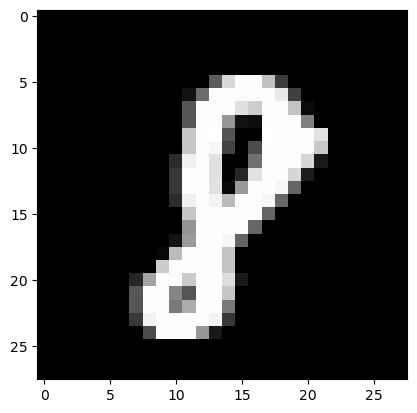

Prediction:  [0]
Label:  0


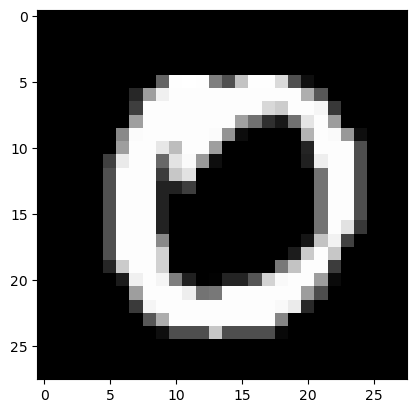

In [15]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [9]:
# Finally, let's find the accuracy on the dev set:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[4 3 5 2 9 3 4 0 2 9 4 1 3 9 9 3 7 6 7 8 9 1 3 5 7 9 2 8 3 3 5 8 6 6 1 8 3
 1 0 3 3 8 2 1 5 5 1 9 2 4 6 6 6 1 6 0 1 9 3 3 2 9 0 6 0 2 7 0 2 0 9 1 9 4
 3 5 2 0 6 5 7 0 0 7 8 7 6 6 8 0 5 4 5 9 8 6 6 3 4 5 4 7 9 6 2 5 6 2 3 5 3
 9 8 5 9 6 6 0 6 3 1 8 7 3 8 5 2 8 1 8 2 9 2 2 8 0 3 7 2 7 5 4 7 3 7 0 7 4
 7 4 6 4 3 2 7 7 1 9 2 3 8 4 7 4 2 2 2 9 8 9 5 9 2 4 9 4 6 0 5 1 4 2 2 0 6
 3 9 3 4 4 1 6 1 8 9 4 0 6 2 2 7 2 3 5 0 9 3 8 5 4 8 8 0 3 4 5 0 1 3 7 2 2
 9 8 4 3 6 9 1 1 5 1 7 3 4 9 8 8 6 6 6 6 1 3 6 3 8 9 1 1 6 8 2 0 1 7 8 1 0
 9 8 8 4 6 5 9 9 1 2 2 4 1 7 9 4 9 6 4 3 7 3 4 9 4 1 4 5 9 6 3 7 2 8 2 8 5
 1 9 1 3 0 1 0 7 3 3 9 1 6 8 3 3 2 1 2 7 1 4 1 9 3 3 1 8 7 3 8 9 8 1 9 5 9
 3 9 9 2 8 1 5 1 1 2 7 1 2 9 0 7 7 0 5 1 0 2 4 8 3 2 7 1 8 0 1 8 8 9 8 6 9
 1 4 6 4 1 9 7 0 1 3 4 0 6 2 2 5 2 9 8 6 8 9 6 0 2 6 4 9 2 3 6 8 2 3 5 9 6
 8 6 4 8 9 0 2 7 2 8 4 4 2 3 3 4 2 9 1 2 9 5 5 9 7 6 5 6 8 5 2 2 1 8 1 6 4
 7 2 1 5 0 4 0 6 8 4 7 3 2 1 1 7 3 7 7 3 7 4 9 8 6 7 9 8 4 8 1 7 3 6 5 8 1
 3 9 0 9 5 9 8 3 4 1 5 8 

0.838